In [ ]:
# !curl -L -o datasets/fraud-detection.zip\
#   https://www.kaggle.com/api/v1/datasets/download/kartik2112/fraud-detection
# !unzip -o -d datasets datasets/fraud-detection.zip

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

In [3]:
data = pd.read_csv('datasets/fraudTrain.csv')
data = data.head(1_000_000)

In [4]:
data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1000000 non-null  int64  
 1   trans_date_trans_time  1000000 non-null  str    
 2   cc_num                 1000000 non-null  int64  
 3   merchant               1000000 non-null  str    
 4   category               1000000 non-null  str    
 5   amt                    1000000 non-null  float64
 6   first                  1000000 non-null  str    
 7   last                   1000000 non-null  str    
 8   gender                 1000000 non-null  str    
 9   street                 1000000 non-null  str    
 10  city                   1000000 non-null  str    
 11  state                  1000000 non-null  str    
 12  zip                    1000000 non-null  int64  
 13  lat                    1000000 non-null  float64
 14  long                   1000000

In [6]:
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])
data['trans_hour'] = data['trans_date_trans_time'].dt.hour
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Unnamed: 0             1000000 non-null  int64         
 1   trans_date_trans_time  1000000 non-null  datetime64[us]
 2   cc_num                 1000000 non-null  int64         
 3   merchant               1000000 non-null  str           
 4   category               1000000 non-null  str           
 5   amt                    1000000 non-null  float64       
 6   first                  1000000 non-null  str           
 7   last                   1000000 non-null  str           
 8   gender                 1000000 non-null  str           
 9   street                 1000000 non-null  str           
 10  city                   1000000 non-null  str           
 11  state                  1000000 non-null  str           
 12  zip                    1000000 non-null 

In [7]:
data.drop(columns=['Unnamed: 0', 'cc_num', 'zip']).describe()

,trans_date_trans_time,amt,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,trans_hour
count,1000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2019-08-04 13:08:58.062761,70.261629,38.533523,-90.226580,8.901336e+04,1.344077e+09,38.533483,-90.226665,0.005701,12.805933
min,2019-01-01 00:00:18,1.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.027785,-166.671242,0.000000,0.000000
25%,2019-05-05 06:39:18.750000,9.640000,34.620500,-96.798000,7.430000e+02,1.336200e+09,34.732331,-96.900125,0.000000,7.000000
50%,2019-08-05 09:56:59,47.420000,39.354300,-87.476900,2.456000e+03,1.344161e+09,39.364497,-87.436819,0.000000,14.000000
75%,2019-11-17 05:31:43.500000,83.050000,41.894800,-80.158000,2.047800e+04,1.353130e+09,41.954618,-80.230355,0.000000,19.000000
max,2020-02-14 12:39:35,28948.900000,66.693300,-67.950300,2.906700e+06,1.360846e+09,67.510267,-66.950902,1.000000,23.000000
std,NaN,160.298029,5.076554,13.762686,3.023267e+05,9.704801e+06,5.110954,13.775012,0.075289,6.817556


In [8]:
# data.isna().sum()

In [9]:
print(data['is_fraud'].value_counts())
print(f'Fraud percentage: {data['is_fraud'].mean() * 100:.3f}%')

is_fraud
0    994299
1      5701
Name: count, dtype: int64
Fraud percentage: 0.570%


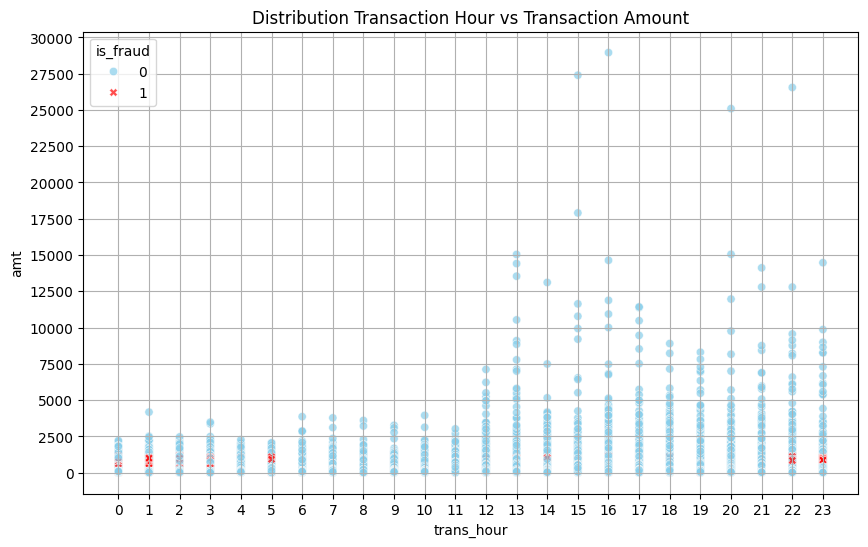

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='trans_hour', y='amt', hue='is_fraud', alpha=.7, 
                palette=['skyblue', 'red'], style='is_fraud', markers=['o', 'X'])
plt.grid(True)
plt.title('Distribution Transaction Hour vs Transaction Amount')
plt.xticks(np.arange(0, 24, 1))
plt.yticks(np.arange(0, 31_000, 2500))
plt.show()

1,000,000


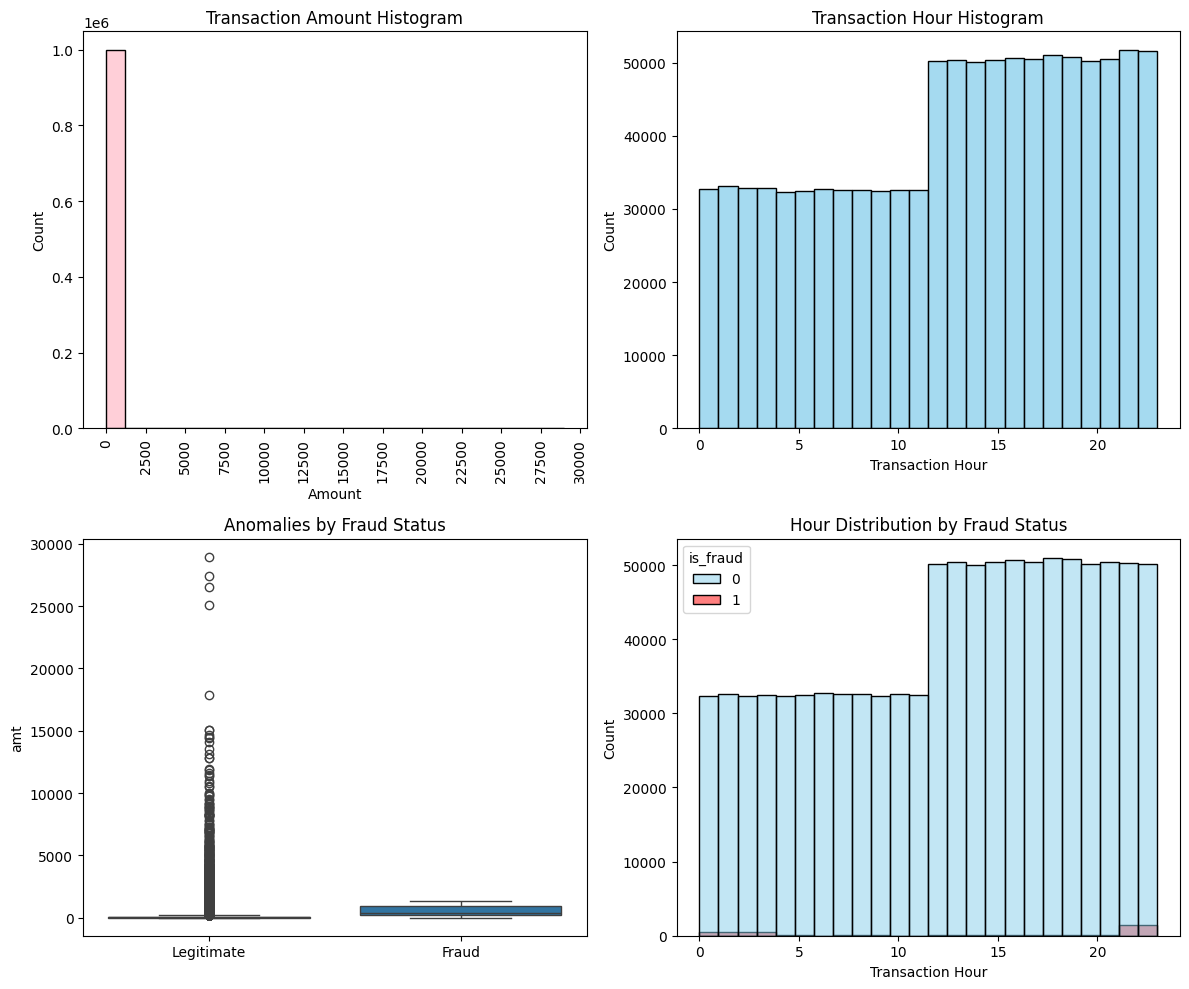

In [11]:
# data=data[:100_000]
print(f'{len(data):,}')
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
ax1 = sns.histplot(data=data, x='amt', bins=24, color='pink')
ax1.set_title('Transaction Amount Histogram')
ax1.set_xticks(np.arange(0, 31000, 2500))
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
ax1.set_xlabel('Amount')

plt.subplot(2, 2, 2)
ax2 = sns.histplot(data=data, x='trans_hour', bins=24, color='skyblue')
ax2.set_title('Transaction Hour Histogram')
ax2.set_xlabel('Transaction Hour')

plt.subplot(2, 2, 3)
ax3 = sns.boxplot(data, y='amt', x='is_fraud')
ax3.set_title('Anomalies by Fraud Status')
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Legitimate', 'Fraud'])
ax3.set_xlabel('')

plt.subplot(2, 2, 4)
ax4 = sns.histplot(data, x='trans_hour', bins=24, hue='is_fraud', palette=['skyblue', 'red'])
ax4.set_title('Hour Distribution by Fraud Status')
ax4.set_xlabel('Transaction Hour')

plt.tight_layout()
plt.show()


In [20]:
data['distance'] = np.sqrt((data['lat'] - data['merch_lat'])**2 + 
                           (data['long'] - data['merch_long'])**2)
features = data[['amt', 'trans_hour']]
model = IsolationForest(contamination=.057, random_state=37)
# model = IsolationForest(random_state=37)
predictions = model.fit_predict(features)

data['is_anomaly'] = np.where(predictions == -1, 1, 0)

In [21]:
print(f"Number of anomalies detected: {data['is_anomaly'].sum():,}")
print(f"Percentage of anomalies: {data['is_anomaly'].sum() / len(data) *100:.3f}%")

print(f"\nActual Frauds: {data['is_fraud'].sum():,}")
true_positive = data[(data['is_anomaly'] == 1) & (data['is_fraud'] == 1)]
false_positive = data[(data['is_anomaly'] == 1) & (data['is_fraud'] == 0)]
false_negative = data[(data['is_anomaly'] == 0) & (data['is_fraud'] == 1)]
print(f"True positive by Isolation Forest: {len(true_positive):,}")
print(f"False positives identified by Isolation Forest: {len(false_positive):,}")
print(f"False negatives identified by Isolation Forest: {len(false_negative):,}")
print(f"Precision (% correct frauds): {len(true_positive) / data['is_anomaly'].sum() * 100:.2f}%")
print(f"Recall (% frauds identified): {len(true_positive) / (len(true_positive) + len(false_negative)) * 100:.2f}%")

Number of anomalies detected: 56,986
Percentage of anomalies: 5.699%

Actual Frauds: 5,701
True positive by Isolation Forest: 4,353
False positives identified by Isolation Forest: 52,633
False negatives identified by Isolation Forest: 1,348
Precision (% correct frauds): 7.64%
Recall (% frauds identified): 76.36%


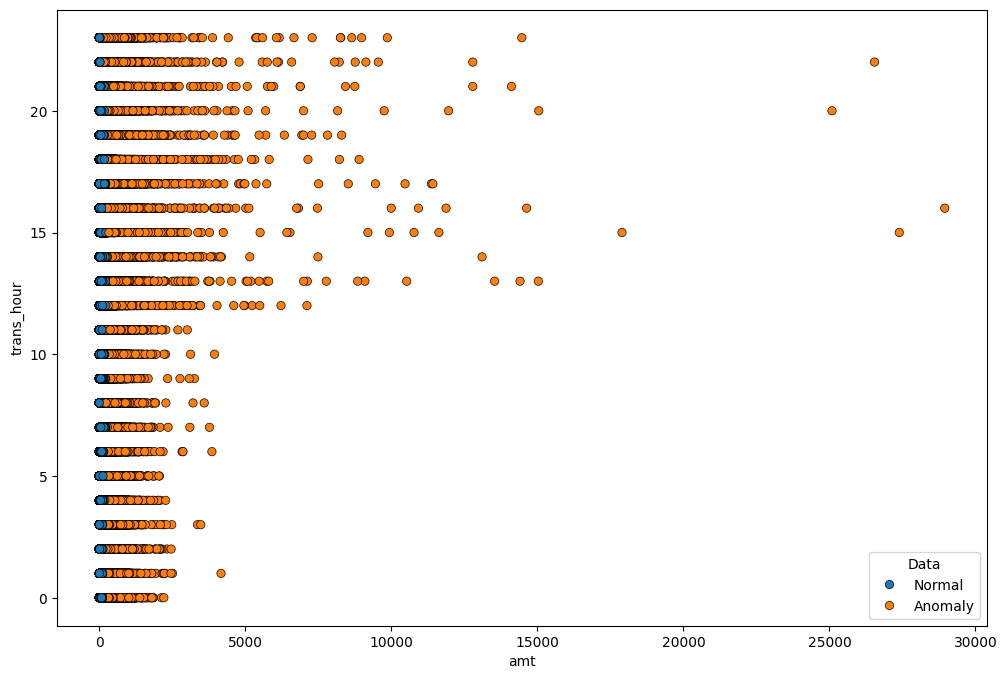

In [22]:
plt.figure(figsize=(12, 8))
ax = sns.scatterplot(data=data.assign(Data=data['is_anomaly'].map({0:'Normal',1:'Anomaly'})), 
                     x='amt', y='trans_hour', hue='Data', edgecolors='k')
plt.show()

In [23]:
print(f"Statistics for Normal: ")
print(data[data['is_anomaly'] == 0][['amt', 'trans_hour', 'distance']].describe())

Statistics for Normal: 
                 amt     trans_hour       distance
count  943014.000000  943014.000000  943014.000000
mean       50.394110      12.851926       0.765501
std        44.471133       6.697919       0.284773
min         1.000000       0.000000       0.000239
25%         9.120000       7.000000       0.564856
50%        43.510000      14.000000       0.798276
75%        76.040000      18.000000       0.977366
max       232.680000      23.000000       1.413364


In [24]:
print(f"Statistics for Anomaly: ")
print(data[data['is_anomaly'] == 1][['amt', 'trans_hour', 'distance']].describe())

Statistics for Anomaly: 
                amt    trans_hour      distance
count  56986.000000  56986.000000  56986.000000
mean     399.032711     12.044836      0.766532
std      550.966302      8.521961      0.284412
min        1.000000      0.000000      0.001192
25%      198.262500      3.000000      0.564760
50%      257.460000     13.000000      0.796513
75%      456.240000     21.000000      0.979005
max    28948.900000     23.000000      1.407182


In [25]:
print(f"Statistics for Actual Normal: ")
print(data[data['is_fraud'] == 0][['amt', 'trans_hour', 'distance']].describe())

Statistics for Actual Normal: 
                 amt     trans_hour       distance
count  994299.000000  994299.000000  994299.000000
mean       67.628451      12.799429       0.765554
std       154.102889       6.796783       0.284768
min         1.000000       0.000000       0.000239
25%         9.600000       7.000000       0.564855
50%        47.200000      14.000000       0.798139
75%        82.470000      19.000000       0.977451
max     28948.900000      23.000000       1.413364


In [26]:
print(f"Statistics for Actual Fraud: ")
print(data[data['is_fraud'] == 1][['amt', 'trans_hour', 'distance']].describe())

Statistics for Actual Fraud: 
               amt   trans_hour     distance
count  5701.000000  5701.000000  5701.000000
mean    529.508574    13.940361     0.766627
std     391.547101     9.722516     0.282069
min       1.180000     0.000000     0.006658
25%     238.780000     2.000000     0.565160
50%     383.070000    22.000000     0.797704
75%     902.100000    23.000000     0.977298
max    1371.810000    23.000000     1.385143


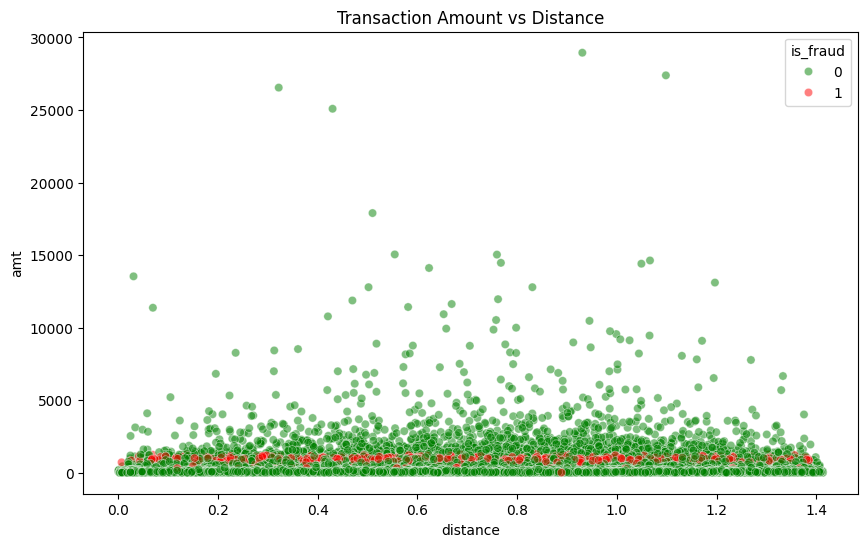

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='distance', y='amt', hue='is_fraud',
                alpha=.5, palette=['green', 'red'])
plt.title('Transaction Amount vs Distance')
plt.show()